# Deskriptiv analyse av barnehagene i Oslo
Under er det gjennomført en enkel utforskende analyse av tallene i foreldreundersøkelsen og bruk av geodata. Analysen danner grunnlaget for dette [dashbordet](https://barnehageguiden.streamlit.app/). Siden analysen er brukt som en innledende undersøkelse av tallene, er beskrivelsen av figurene knapp. Se ellers [README](README.md) for mer utfyllende informasjon om prosjektet. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim
import folium
from geopy.distance import distance
from scipy.stats import norm
from scipy import stats
import requests
from rapidfuzz import process
import re
from geo_func import avstand_score

In [ ]:
#Celle til filtrering. Om noen vil kjøre analysen for egen adresse, er det bare nødvendig å gjøre endringer her. 
år = 2026 #Skriv inn år for å kjøre analysen. Tilgjengelige år er per nå 2023, 2025 og 2026. 
hjem_adresse = "Hedmarksgata 4" #Skriv inn hjemadresse
vekt_undersokelse = 0.5 #Vekten for Foreldreundersøkelsen. 0.3 vil si at man vektlegger disse resultatene 30 pst, mens man vektlegger avstand til barnehagen 70 pst. 

In [3]:
df = pd.read_parquet("data/barnehager_renset.parquet",
engine="fastparquet")

df = df.iloc[df["år"]==år,:]

In [4]:
df_wide = df.pivot_table(
    index =["år", "barnehage", "Eierform"],
    columns = "spørsmål",
    values = "snitt"
).reset_index()

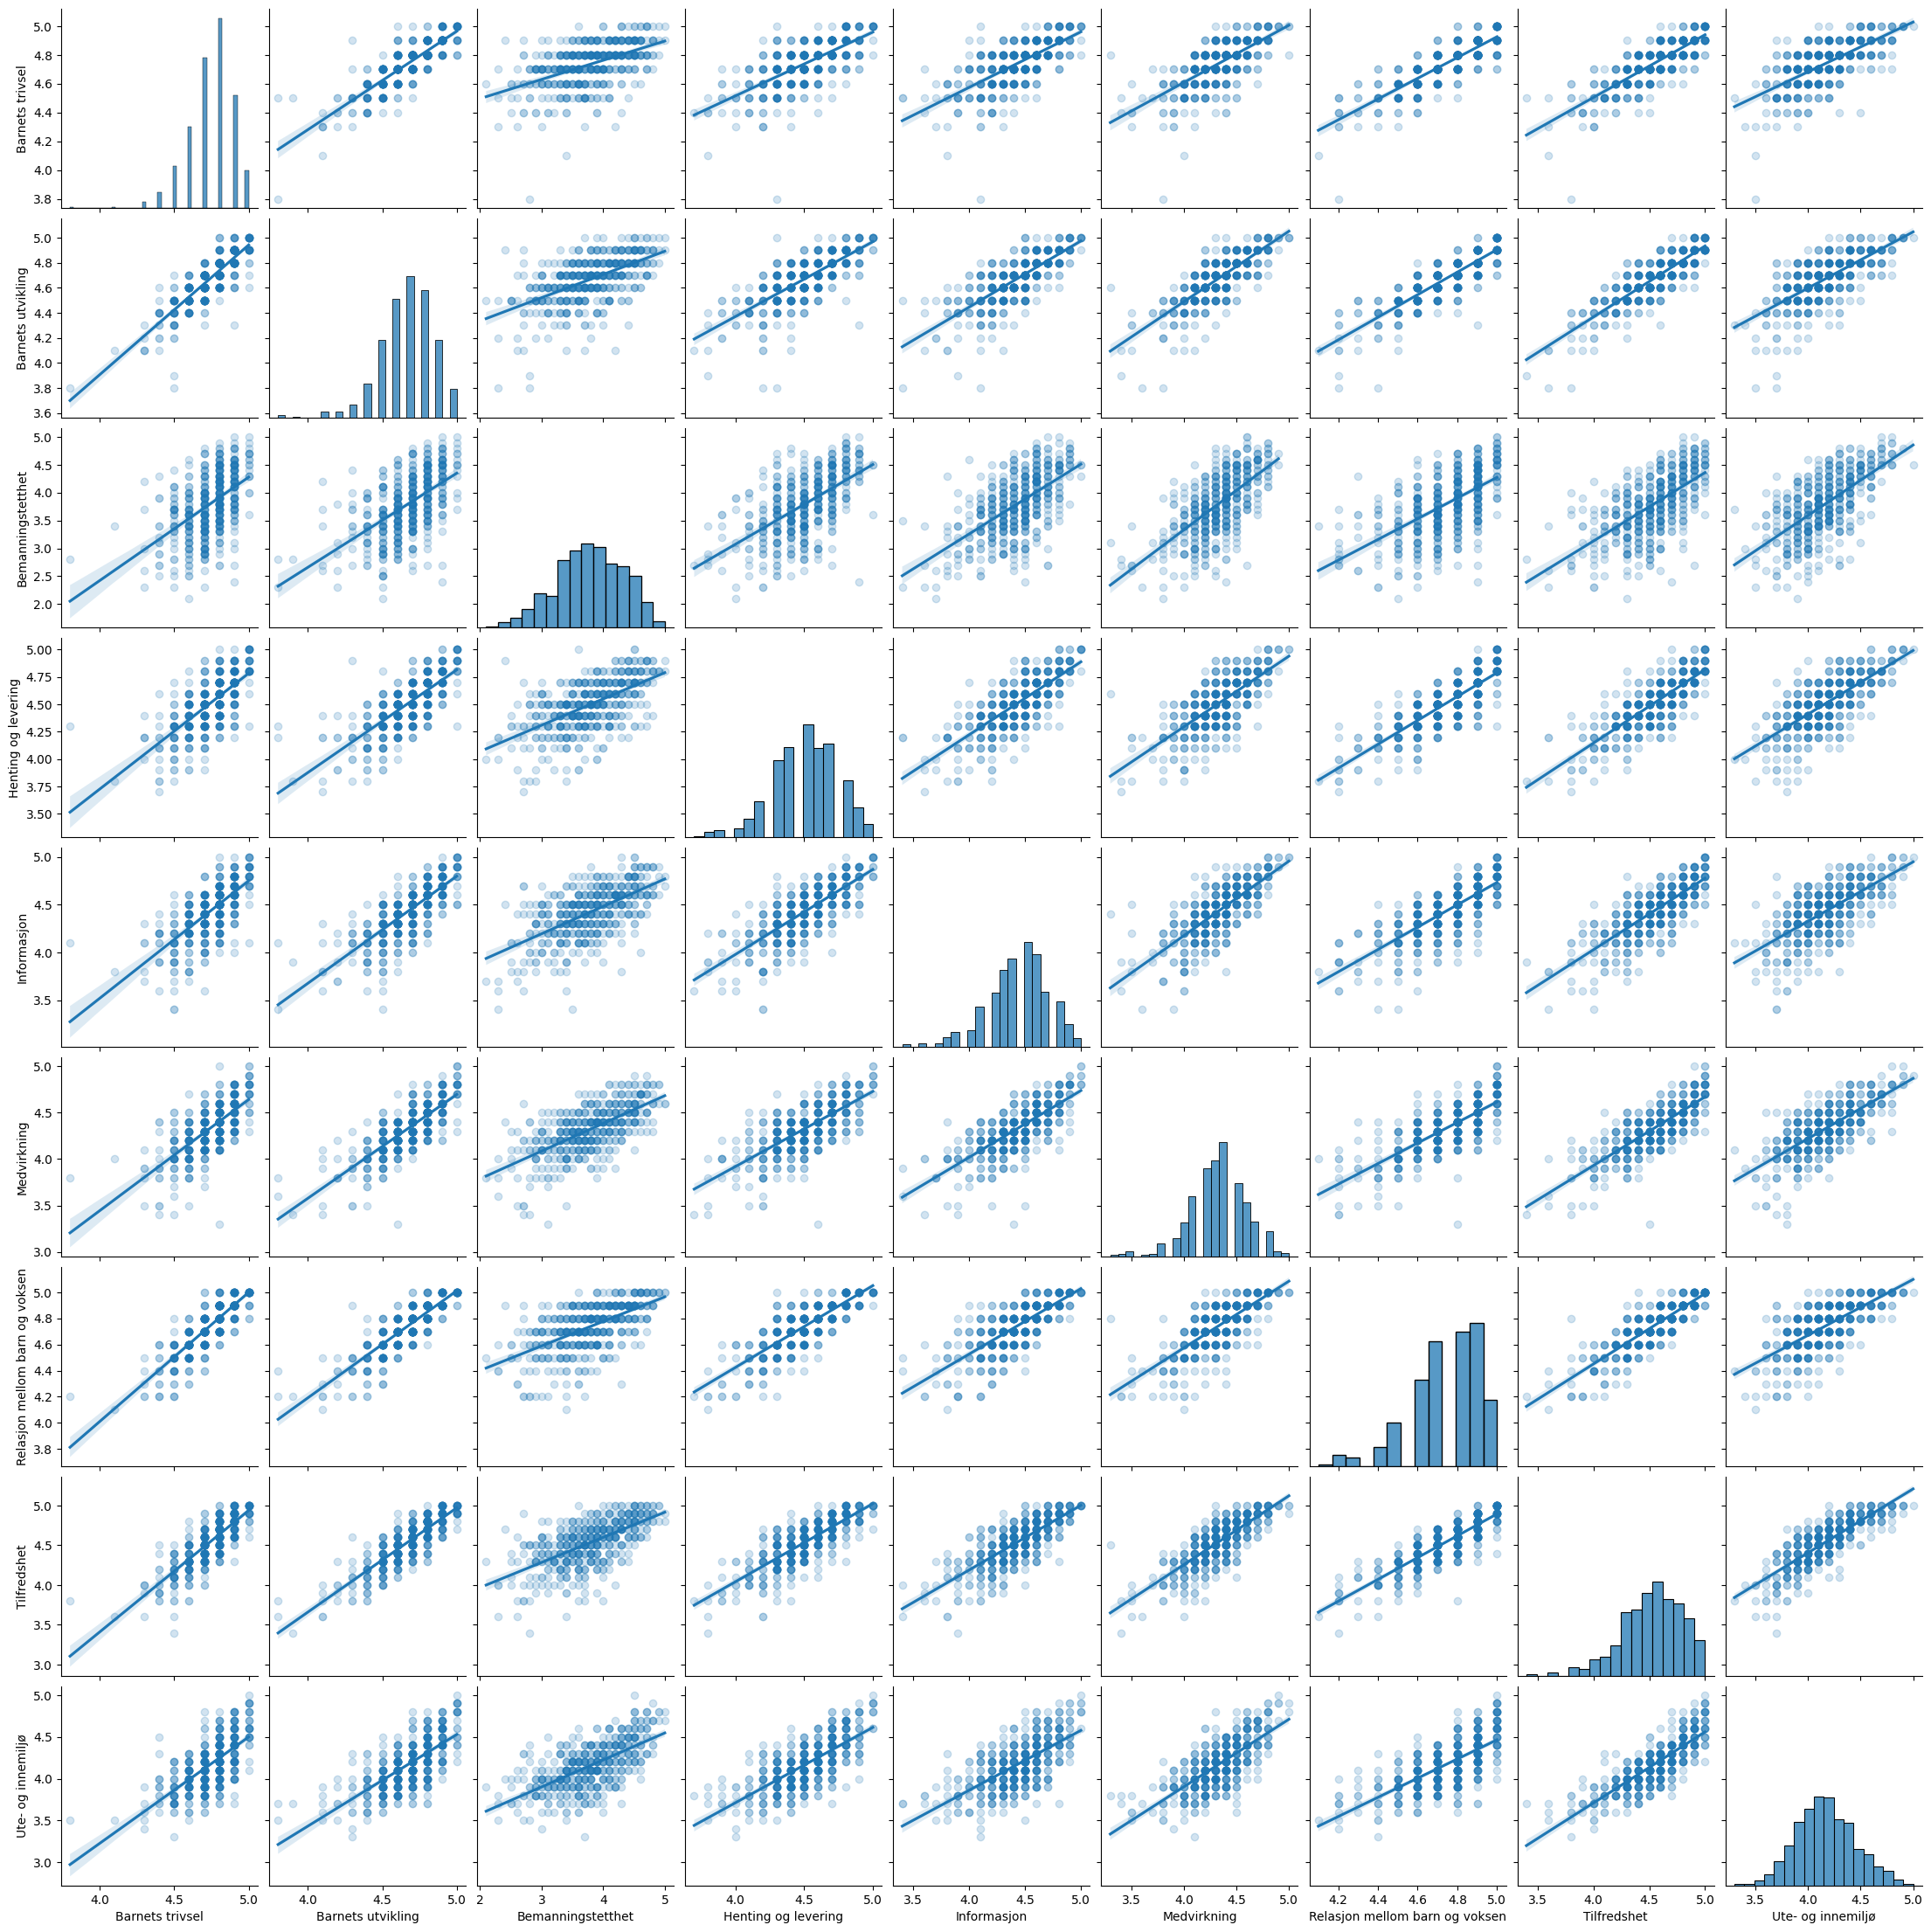

In [5]:
sns.pairplot(data=df_wide.loc[:, df_wide.columns != "år"].select_dtypes(include="number"),
            kind="reg",
            plot_kws = {"scatter_kws":{"alpha":0.2}})
plt.show()

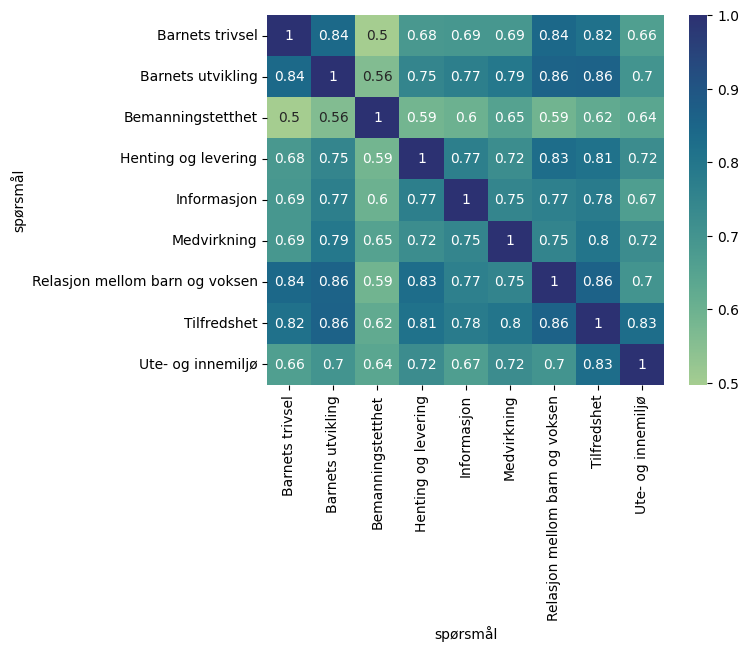

In [6]:
corr_matrix = (
    df_wide.loc[:, df_wide.columns != "år"]
    .select_dtypes(include="number")
    .corr()
)

sns.heatmap(data=corr_matrix,
           cmap="crest",
           annot=True)
plt.show()


Det er en tydelig positiv sammenheng mellom alle indikatorene. Dette bekreftes i varmekartet som fremstiller korrelasjonskoeffisienten mellom de ulike variablene. I de fleste sammenhenger vil det derfor være tilstrekkelig å se på færre indikatorer. Den viktigste indikatoren er antatt å være "tilfredshet" som oppsummerer det totale inntrykket av barnehagen. I tilfeller der det ikke finnes verdier for variabelen "tilfredshet" brukes gjennomsnittet av variablene som allerede finnes. 

Som et suplement til den totale tilfredsheten beregner jeg en ny variabel som er basert på gjennomsnittet av de øvrige indikatorene. Dersom disse indikatorene fanget opp alt av foreldres inntrykk av barnehagen, foreldre vektet kategoriene likt og foreldre svarer logisk konsistent, burde denne variabelen og "tilfredshet" vært identisk. Dette er mest sannsynlig ikke tilfelle da minst et av kriteriene (mest sannsynlig alle) listet opp over ikke er oppfylt. 

Punktdiagrammet under viser at det er tett sammenheng mellom den totale tilfredsheten og snittet av de andre indikatorene. Sammenhengen er imidlertid ikke perfekt. 

In [7]:
#Fyll NAs basert på gjennomsnittet for barnehagen
num_cols = (
    df_wide.loc[:, df_wide.columns != "år"]
    .select_dtypes(include="number")
    .columns
)

df_wide[num_cols] = df_wide[num_cols].apply(
    lambda row: row.fillna(row.mean()), axis=1
)

#Lager nytt mål basert på gjennomsnittlig score i undersøkelsen. Dropper "tilfredshet" da det er et samlemål
df_wide["Gjennomsnittlig_score"] = df_wide[num_cols.drop("Tilfredshet")].apply(
    lambda row: row.mean(), axis=1
)

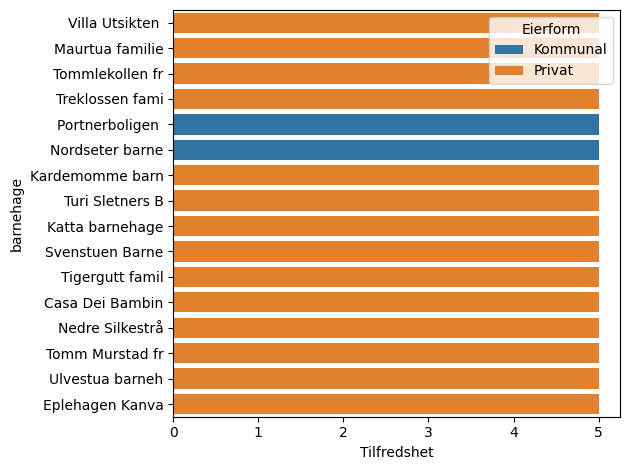

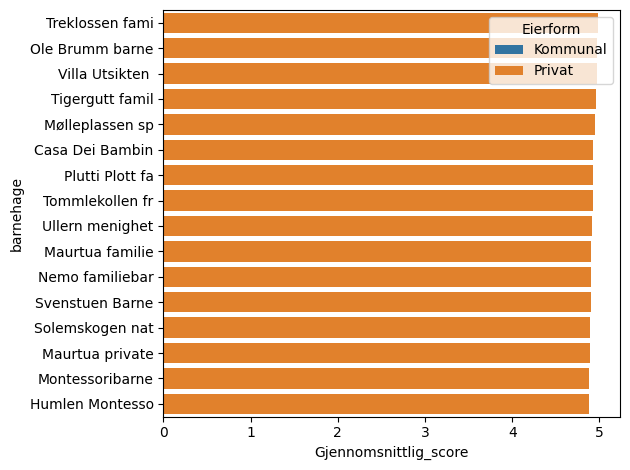

In [8]:
df_sorted_tilfreds = (
    df_wide
        .sort_values("Tilfredshet", ascending=False)
        .iloc[:16])

df_sorted_barnet = (
    df_wide
        .sort_values("Gjennomsnittlig_score", ascending=False)
        .iloc[:16])

order_tilfreds = df_sorted_tilfreds["barnehage"].tolist()
order_barnet = df_sorted_barnet["barnehage"].tolist()

sns.barplot(
    data=df_sorted_tilfreds,
    y="barnehage",
    x="Tilfredshet",
    hue="Eierform",
    dodge=False,
    order=order_tilfreds
)
plt.yticks(ha="right",
           ticks=range(len(df_sorted_tilfreds["barnehage"])),
           labels=[v[:15] for v in df_sorted_tilfreds['barnehage']])

plt.tight_layout()
plt.show()

ax2 = sns.barplot(
    data=df_sorted_barnet,
    y="barnehage",
    x="Gjennomsnittlig_score",
    hue="Eierform",
    dodge=False,
    order=order_barnet
)
plt.yticks(ha="right",
           ticks=range(len(df_sorted_barnet["barnehage"])),
           labels=[v[:15] for v in df_sorted_barnet['barnehage']])

plt.tight_layout()
plt.show()

Som ventet er det mange av de samme barnehagene som gjør det bra både på total tilfredshet og på gjennomsnittlig score på de andre indikatorene. Dette kommer også frem i punktdiagrammet under.

Private barnehager utgjør en større andel av topplisten for begge indikatorene. Dette er tilfellet til tross for at det er færre private barnehager i datasettet. 

Figurene under viser at private barnehager generelt scorer i snitt signifikant bedre enn kommunale i Oslo. Den beste og dårligste poengsummen er bedre sammenlignet med kommunale og spredningen er mindre. 

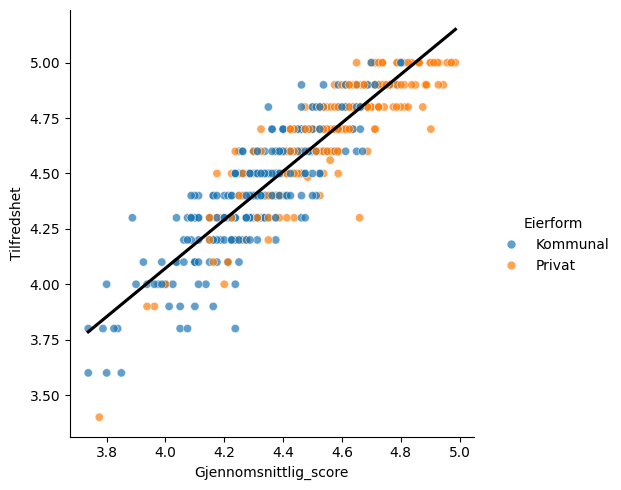

In [9]:
g = sns.relplot(data=df_wide,
            x="Gjennomsnittlig_score",
            y="Tilfredshet",
            hue="Eierform",
            kind="scatter",
            alpha=0.7
                )

g.map_dataframe(
    sns.regplot,
    x="Gjennomsnittlig_score",
    y="Tilfredshet",
    scatter=False,
    ci=None,
    color="black"
)
plt.show()

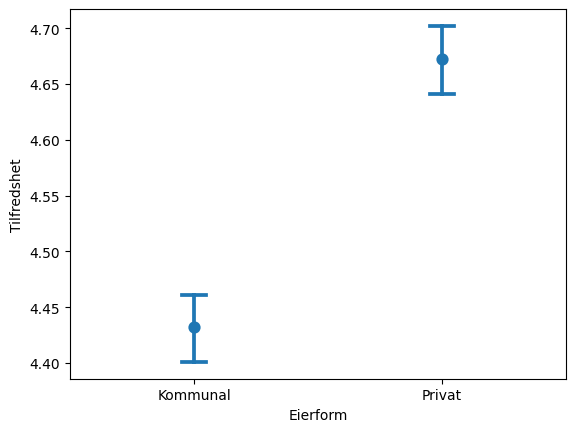

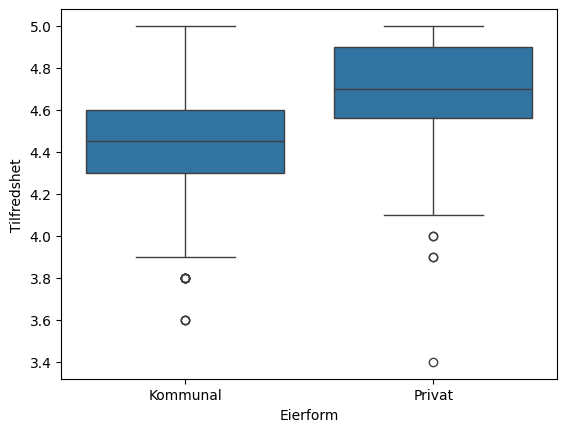

In [10]:
sns.pointplot(data=df_wide, 
              y="Tilfredshet", x="Eierform",  
              errorbar=('ci', 95), #Burde egentlig regnes separat for disse men er her på den trygge siden
             capsize=0.1,
             linestyle="none")
plt.show()

sns.boxplot(data=df_wide, 
              y="Tilfredshet", x="Eierform")
plt.show()

## Avstand til barnehage

In [11]:
query = """
[out:json];
area[name="Oslo"]->.oslo;
nwr[amenity=kindergarten](area.oslo);
out center;
""" #Finner alle obs som er tagget som barnehage i Oslo. Out center gir koordinatene for midtpunktet til hvert element
r = requests.post("https://overpass-api.de/api/interpreter", data=query)
elementer = r.json()["elements"] #Består av en en dict på to nivåer. Lat og long ligger i nivå 1, mens navn ligger i nivå to (tags{name})

koord = [
    {
        "navn": e.get("tags", {}).get("name", ""),
        "lat": e.get("lat") or e.get("center", {}).get("lat"),
        "lon": e.get("lon") or e.get("center", {}).get("lon")
    }
    for e in elementer if e.get("tags", {}).get("name") #Filtrerer bort elementer som ikke har et navn. None = false
]

In [12]:
def normaliser(navn, støyende_ord = ["barnehage", "as", "avd", "famliebarnehage"]):
    navn = navn.lower()
    for ord in støyende_ord:
        navn = re.sub(rf"\b{ord}\b", "", navn)
    return " ".join(navn.split())

In [13]:
#Lager funksjon med fuzzy søk. Dvs at det ikke trenger å være eksakt match. Må vurdere terkelsn her
def geocode_fuzzy(navn, koord, terskel=90):
    navn_liste = [normaliser(b["navn"]) for b in koord]
    match, score, idx = process.extractOne(
        normaliser(navn), navn_liste)
    if score >= terskel:
        return koord[idx]["lat"], koord[idx]["lon"], score, koord[idx]["navn"]
    print(f"Ingen god match: '{navn}' (beste: '{match}', score: {score})")
    return None, None, None, None

In [14]:
barnehage_navn = df_wide["barnehage"].tolist()           

df_geo = pd.DataFrame({
    "barnehage": barnehage_navn,        
    "Latitude": [np.nan] * len(barnehage_navn),
    "Longitude": [np.nan] * len(barnehage_navn),
    "Score": [np.nan] * len(barnehage_navn),
    "Barnehage_fra_api": pd.array([""] * len(barnehage_navn), dtype="string")
})

for idx in df_geo.index:
    lat, lon, score, barnehage_api = geocode_fuzzy(df_geo.iloc[idx, 0], koord)
    df_geo.iloc[idx, 1] = lat
    df_geo.iloc[idx, 2] = lon
    df_geo.iloc[idx, 3] = score
    df_geo.iloc[idx, 4] = barnehage_api

Ingen god match: 'Akersløkka barnehage' (beste: 'keyserløkka', score: 76.19047619047619)
Ingen god match: 'Brennastubben familiebarnehage AS' (beste: 'monoliten familiebarnehage', score: 75.0)
Ingen god match: 'Gregers barnehage' (beste: 'skredderstua', score: 64.28571428571429)
Ingen god match: 'Hakkebakkeskogen Daniel Walstadsvei' (beste: 'akersbakken', score: 68.57142857142857)
Ingen god match: 'Hakkebakkeskogen Dr Rustadsvei' (beste: 'akersbakken', score: 68.57142857142857)
Ingen god match: 'Hakkebakkeskogen Fyrstikkbakken' (beste: 'solbakken', score: 72.0)
Ingen god match: 'Hakkebakkeskogen Kastanjeveien' (beste: 'bauneveien', score: 75.78947368421052)
Ingen god match: 'Hakkebakkeskogen Kirkesvingen' (beste: 'lørensvingen', score: 73.63636363636364)
Ingen god match: 'Hakkebakkeskogen Kolderupsvei' (beste: 'akersbakken', score: 68.57142857142857)
Ingen god match: 'Hakkebakkeskogen Vækerøveien' (beste: 'vårveien', score: 72.0)
Ingen god match: 'Maurtua familiebarnehage' (beste: 'mon

In [15]:
print(f"Antall missing: {len(df_geo[df_geo["Latitude"].isna()])}")
print(df_geo[df_geo["Latitude"].isna()][["barnehage", "Barnehage_fra_api", "Score"]])

df_geo = df_geo.dropna(subset=["Latitude"])

Antall missing: 23
                                             barnehage Barnehage_fra_api  \
2                                 Akersløkka barnehage              <NA>   
49                   Brennastubben familiebarnehage AS              <NA>   
131                                  Gregers barnehage              <NA>   
141                Hakkebakkeskogen Daniel Walstadsvei              <NA>   
142                     Hakkebakkeskogen Dr Rustadsvei              <NA>   
143                    Hakkebakkeskogen Fyrstikkbakken              <NA>   
144                     Hakkebakkeskogen Kastanjeveien              <NA>   
145                      Hakkebakkeskogen Kirkesvingen              <NA>   
146                      Hakkebakkeskogen Kolderupsvei              <NA>   
149                       Hakkebakkeskogen Vækerøveien              <NA>   
294                           Maurtua familiebarnehage              <NA>   
295  Maurtua private familiebarnehage AS avd Beverv...              <

Det er totalt 23 barnehager som ikke blir matchet. Jeg fjerner disse barnehagene fra videre analyse da de ikke er aktuelle for meg, men det er mulig å bruke litt tid på å manuelt legge inn koordinater eller på annen måte sikre at de er med videre i analysen. 

### Kombinasjon av avstand og score i foreldreundersøkelsen
For å finne vår beste barnehagematch er det nødvendig å kombinere tallene fra Foreldreundersøkelsen og avstand fra hjemmet.

Det er likevel viktig å være klar over at dette kan få noen rare utslag. Mange barnehager som ligger i nærheten er tungvinte å levere til i forbindelse med jobb. Dette er barnehager som ikke er på vei til jobb eller i nærheten av kollektiv transport. På samme måte finnes det barnehager som ligger lengre unna som likevel kan være gode alternativer fordi de er enkle å levere til.

Det er mange måter å kombinere avstand og score fra foreldreundersøkelsen. En metode, som gir en intuitiv tolkning, er å la begge være på den samme skalaen. Dette gjør det enkelt å sammenstille dem. Siden Foreldreundersøkelsen tar i bruk en skala mellom 1 og 5, er det enkelst å også bruke den for avstandsmålet. 

Scoren på total tilfredshet bruker imidlertid ikke hele skalaen. I 2026 er den største verdien er `5`, mens den minste verdien er så høy som `3,4`. Dersom avstandsmålet hadde brukt hele skalaen, ville målet fått uforholdsmessig stor vekt. En bedre metode er derfor å bare bruke skalaen mellom 3,4 og 5. Deretter kan dette vektes senere. 

In [16]:
geolocator = Nominatim(user_agent="barnehager") 
def geocode_bedrift(navn):
    query = f"{navn}, Oslo, Norge"
    try:
        location =geolocator.geocode(query)
        if location:
            return location.latitude, location.longitude
    except Exception as e:
        print(f"Feil ved geokoding: {e} for {query}")
        return None, None

In [17]:
#Legger til hjem
hjem = geocode_bedrift(hjem_adresse) #Hjemadresse er definert i toppen av arket for enkel oppdatering

#Lager variabel med avstand mellom hjem og barnehage
df_geo["Avstand_hjem_m"] = df_geo.apply(
    lambda row: distance((row["Latitude"], row["Longitude"]), hjem).m, axis=1
)

print(df_geo.head())

                       barnehage   Latitude  Longitude  Score  \
0  Abildsø menighetsbarnehage AS  59.879716  10.827346  100.0   
1          Akersbakken barnehage  59.925532  10.747698  100.0   
3    Akersveien Kanvas-barnehage  59.923061  10.747756  100.0   
4               Alleen barnehage  59.914680  10.794545  100.0   
5     Almelia - Sio barnehage AS  59.951557  10.730511  100.0   

             Barnehage_fra_api  Avstand_hjem_m  
0   Abildsø menighetsbarnehage     3971.338840  
1        Akersbakken barnehage     2903.845656  
3  Akersveien Kanvas-barnehage     2742.393769  
4             Alleen barnehage      641.506297  
5      Almelia - SiO barnehage     5695.041328  


In [18]:
#Lager avstandscore basert på funksjon
df_geo["Avstand_score"] = avstand_score(df_geo["Avstand_hjem_m"], 
                                             min=df_wide["Tilfredshet"].min(),
                                             maks=df_wide["Tilfredshet"].max()
                                            )

In [19]:
#Merger datasett
df_merged = pd.merge(
    df_wide, 
    df_geo, 
    on="barnehage", 
    how="left")

In [20]:
#Regner ut totalscore
vekt_avstand = 1-vekt_undersokelse

df_merged["Total_score"] = df_merged["Tilfredshet"]*vekt_undersokelse + df_merged["Avstand_score"]*vekt_avstand
df_merged["Total_score_gjennomsnitt_indikatorer"] = df_merged["Gjennomsnittlig_score"]*vekt_undersokelse + df_merged["Avstand_score"]*vekt_avstand


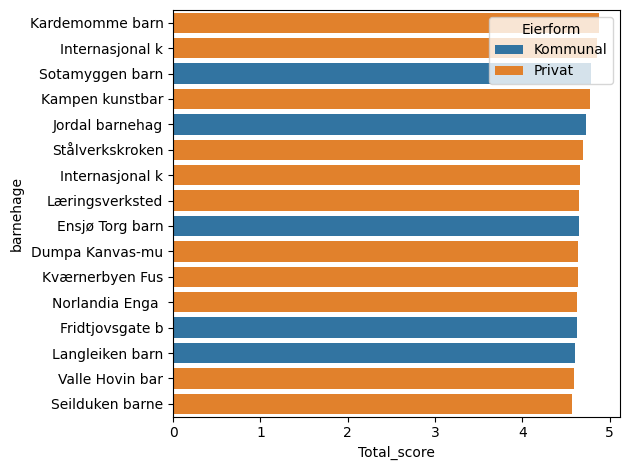

In [21]:
df_sorted_merged = (
    df_merged
        .sort_values("Total_score", ascending = False)
        .iloc[:16])


sns.barplot(data=df_sorted_merged,
            y="barnehage",
            x="Total_score",
           hue="Eierform",
           dodge = False)
plt.yticks(ha="right",
           ticks=range(len(df_sorted_merged["barnehage"])),
           labels=[v[:15] for v in df_sorted_merged['barnehage']])
plt.tight_layout()
plt.show()

Figurene viser at det Kardemomme barnehage som er den beste totalpakka for oss. 

Topplisten er dominert av private barnehager. Det sies at det er vanskelig å komme inn i en privat barnehage dersom man ikke har den på førsteplass. En mulighet er derfor å ha en privat barnehage på førsteplass og fylle opp resten av søknaden med kommunale. Det er derfor interessant å bare se på de kommunale barnehagene.

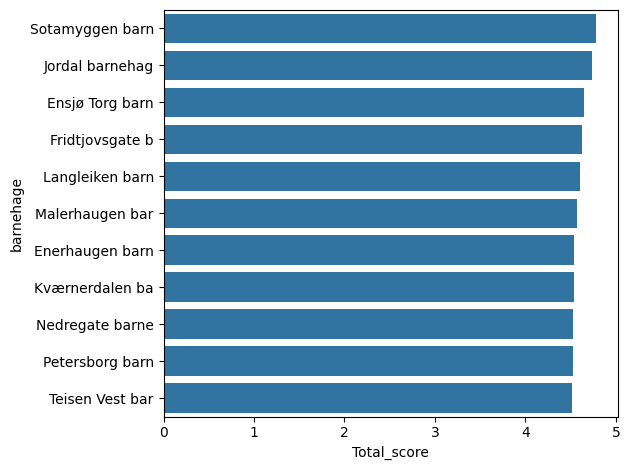

In [22]:
df_sorted_merged_kommunal = (
    df_merged.loc[df_merged["Eierform"]=="Kommunal",:]
        .sort_values("Total_score", ascending = False)
        .iloc[:11])

sns.barplot(data=df_sorted_merged_kommunal,
            y="barnehage",
            x="Total_score")
plt.yticks(ha="right",
           ticks=range(len(df_sorted_merged_kommunal["barnehage"])),
           labels=[v[:15] for v in df_sorted_merged_kommunal["barnehage"]])
plt.tight_layout()
plt.show()

In [23]:
#Mapper på kart
kart = folium.Map(
    location=hjem,
    zoom_start=14,
)

for idx in df_merged.index:
    if not pd.isna(df_merged.loc[idx, "Latitude"]):
        folium.Marker(
            location=[
                df_merged.loc[idx, "Latitude"],
                df_merged.loc[idx, "Longitude"]
            ],
            tooltip = df_merged.loc[idx, "barnehage"],
            popup=f"{df_merged.loc[idx, "barnehage"]}, Tilfredshet: {df_merged.loc[idx, "Tilfredshet"]}"
        ).add_to(kart)

#Legger til hjem

folium.Marker(
    location = hjem,
    tooltip = "Hjem",
    popup="Hjem",
    icon=folium.Icon(color="red")
).add_to(kart)
kart

In [24]:
df_merged.to_parquet("data/foreldreundersokelse_geo.parquet", 
                     index=False, engine="pyarrow")